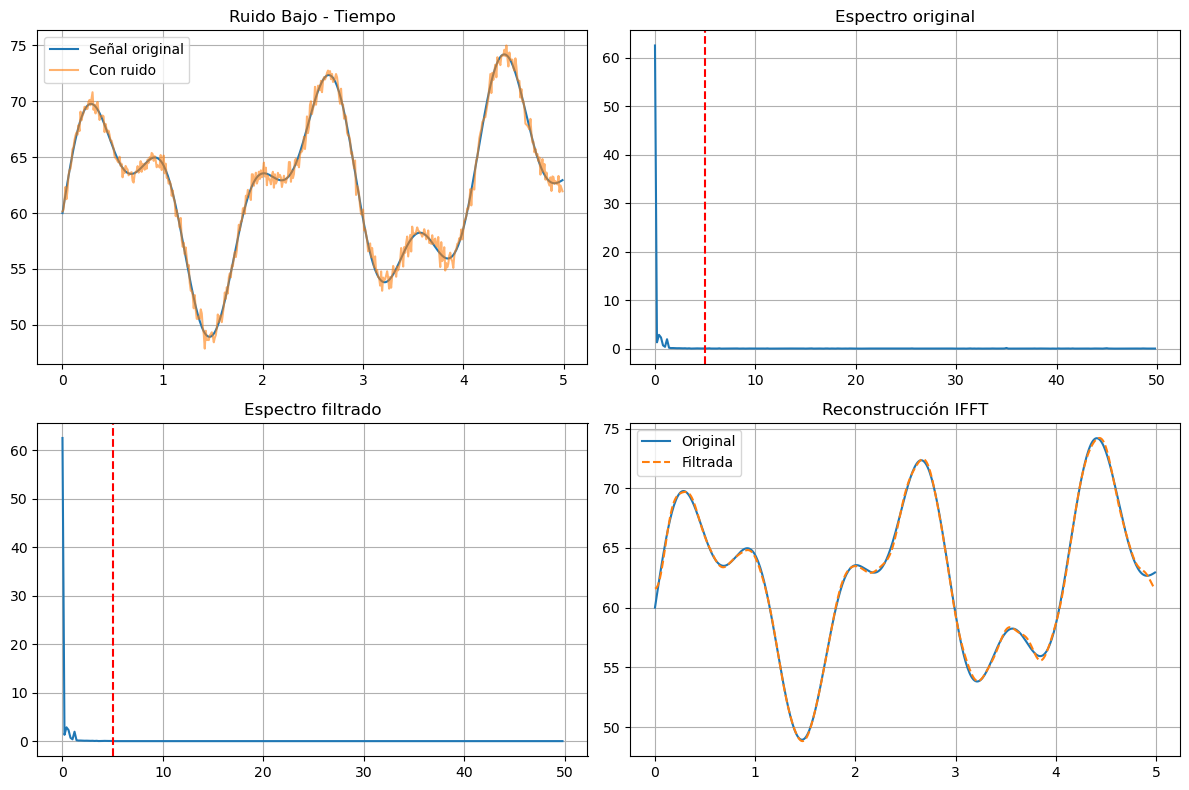

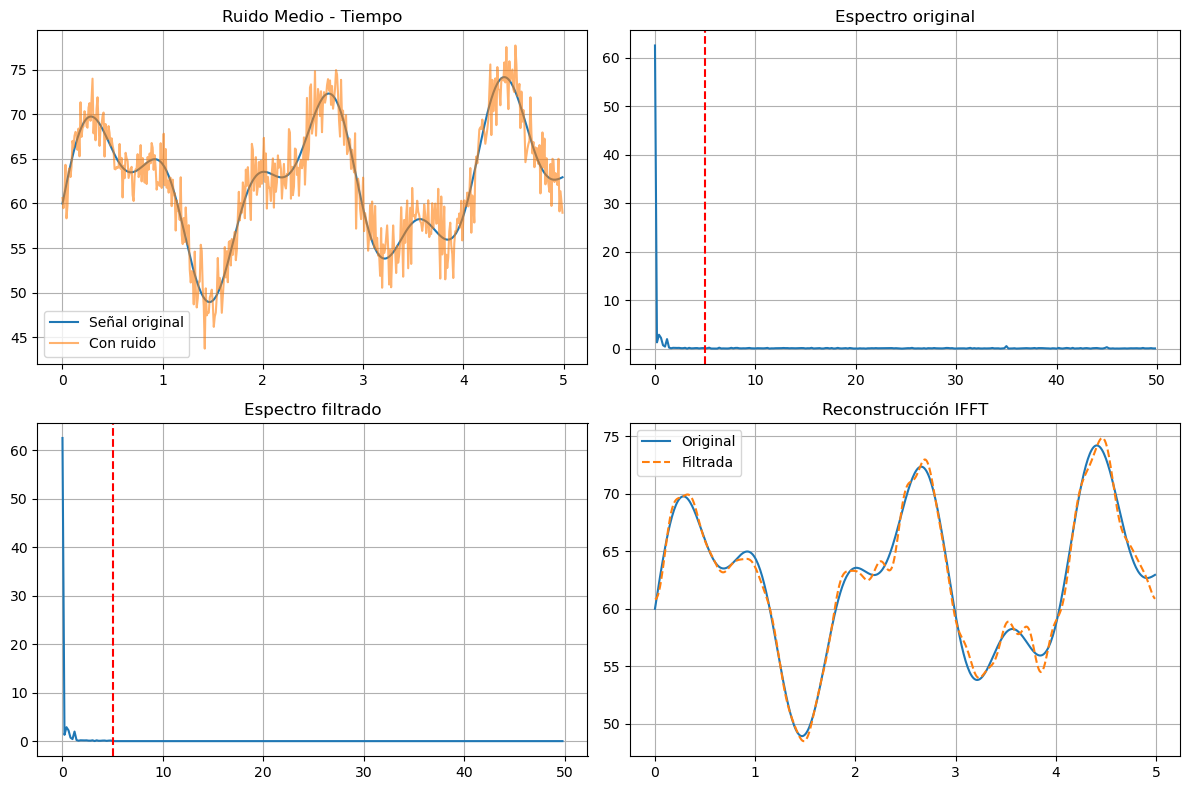

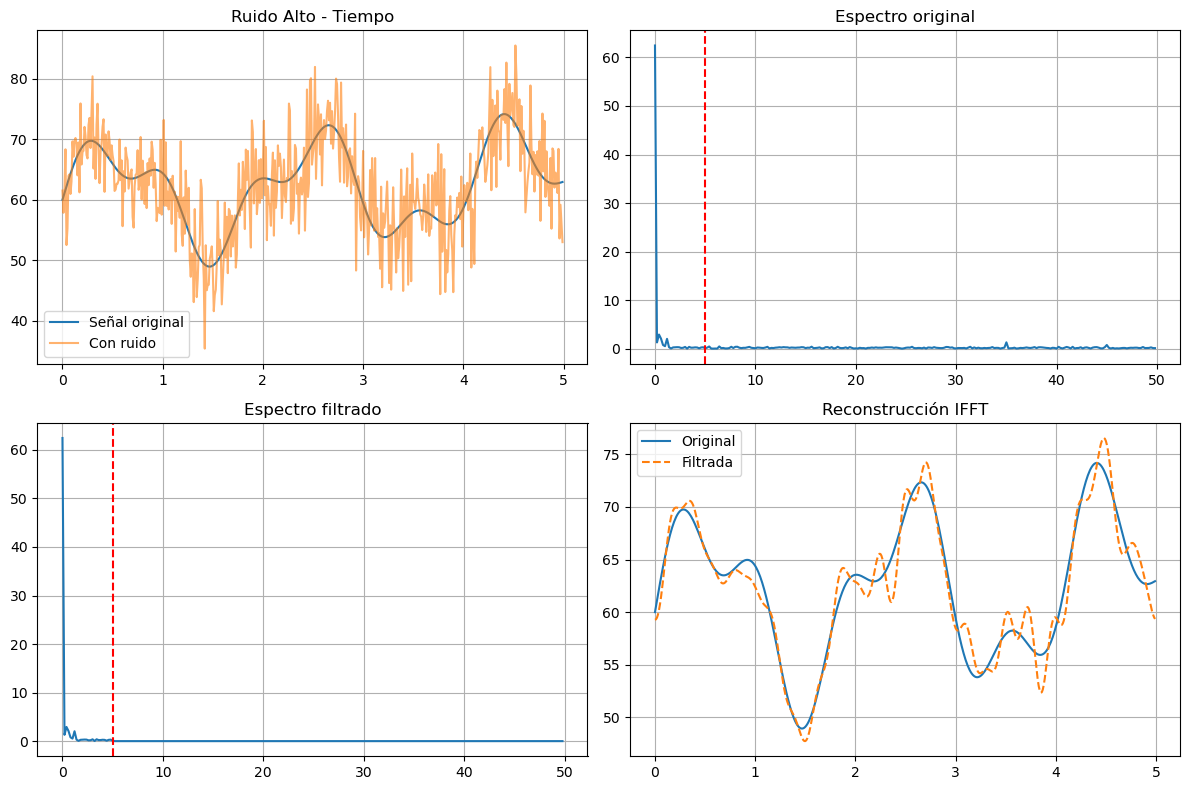

,Escenario,Sigma,SNR Antes,SNR Después,Mejora,MSE,RMSE
0,Ruido Bajo,0.5,41.551894,49.337606,7.785712,0.045977,0.214421
1,Ruido Medio,2.0,29.510694,39.952058,10.441364,0.399109,0.631750
2,Ruido Alto,5.0,21.551894,32.203320,10.651427,2.376648,1.541638


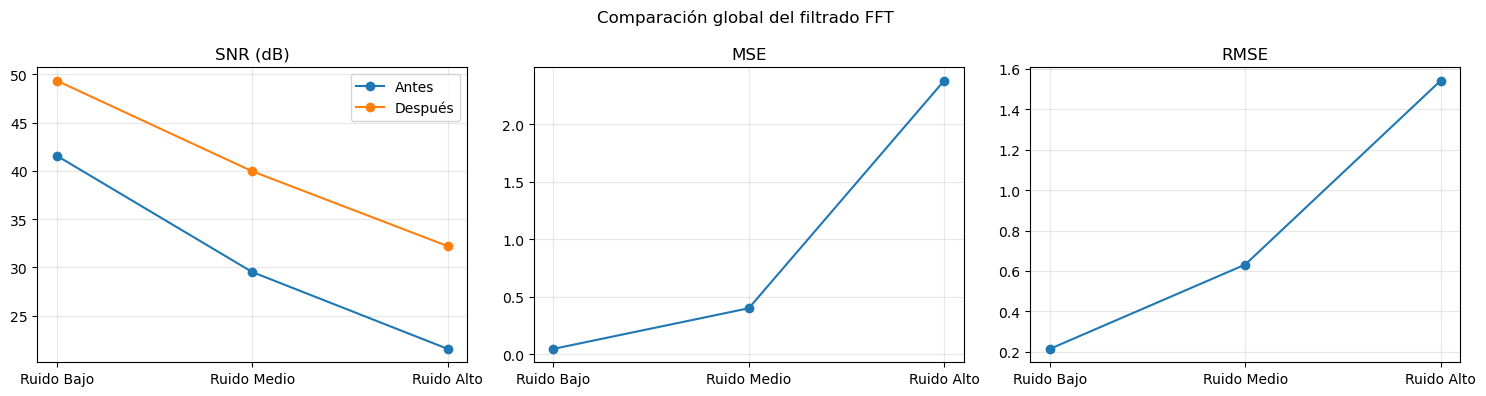

In [11]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# CONFIGURACIÓN GENERAL
# ==================================================

fs = 100        # frecuencia de muestreo en Hz
N = 500         # número de muestras
fc = 5.0        # frecuencia de corte del filtro en Hz

# vector de tiempo discreto
t = np.arange(N) / fs

# cerrar figuras previas si existen
plt.close("all")

# ==================================================
# SEÑAL DE CPU (ecuación 4.1)
# ==================================================

def generar_senal():
    A = 60
    A1 = 8
    A2 = 4

    f1 = 0.5
    f2 = 1.2

    # señal determinista con tendencia + oscilaciones
    senal = (
        A
        + A1 * np.sin(2 * np.pi * f1 * t)
        + A2 * np.sin(2 * np.pi * f2 * t)
        + 3 * (np.arange(N) / N)
    )
    return senal

# ==================================================
# RUIDO ADITIVO (ecuación 4.3)
# ==================================================

def agregar_ruido(s, sigma, seed=42):

    # generador reproducible
    rng = np.random.default_rng(seed)

    # ruido blanco gaussiano
    w = rng.normal(0, 1, len(s))

    # combinación de ruido blanco + interferencias sinusoidales
    ruido = (
        sigma * w
        + 0.5 * sigma * np.sin(2 * np.pi * 35 * t)
        + 0.3 * sigma * np.sin(2 * np.pi * 45 * t)
    )

    # señal observada
    x = s + ruido

    return x, ruido

# ==================================================
# FFT + FILTRO PASO BAJO (Ecs. 4.4–4.8)
# ==================================================

def filtrar_fft(x):

    # transformada discreta de Fourier
    X = np.fft.fft(x)

    # eje de frecuencias
    freqs = np.fft.fftfreq(len(x), d=1/fs)

    # copia del espectro para filtrado
    Xf = X.copy()

    # filtro paso bajo: eliminar frecuencias mayores a fc
    Xf[np.abs(freqs) > fc] = 0

    # reconstrucción en tiempo (IFFT)
    x_filtrada = np.real(np.fft.ifft(Xf))

    return x_filtrada, X, Xf, freqs

# ==================================================
# MÉTRICAS DE EVALUACIÓN
# ==================================================

def calcular_metricas(s, ruido, x_filtrada):

    # potencia de la señal original
    Ps = np.mean(s**2)

    # potencia del ruido inicial
    Pn = np.mean(ruido**2)

    # SNR antes del filtrado
    snr_antes = 10 * np.log10(Ps / Pn)

    # error de reconstrucción
    error = s - x_filtrada

    # SNR después del filtrado
    snr_despues = 10 * np.log10(Ps / np.mean(error**2))

    # error cuadrático medio
    mse = np.mean(error**2)

    # raíz del error cuadrático medio
    rmse = np.sqrt(mse)

    return snr_antes, snr_despues, snr_despues - snr_antes, mse, rmse

# ==================================================
# GRÁFICAS POR ESCENARIO
# ==================================================

def graficar_resultados(nombre, s, x, x_filtrada, X, Xf, freqs):

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # solo frecuencias positivas
    mask = freqs >= 0

    # señal en el dominio del tiempo
    axs[0, 0].plot(t, s, label="Señal original")
    axs[0, 0].plot(t, x, alpha=0.6, label="Con ruido")
    axs[0, 0].set_title(f"{nombre} - Tiempo")
    axs[0, 0].legend()
    axs[0, 0].grid()

    # espectro original
    axs[0, 1].plot(freqs[mask], np.abs(X[mask]) / N)
    axs[0, 1].axvline(fc, color="red", linestyle="--")
    axs[0, 1].set_title("Espectro original")
    axs[0, 1].grid()

    # espectro filtrado
    axs[1, 0].plot(freqs[mask], np.abs(Xf[mask]) / N)
    axs[1, 0].axvline(fc, color="red", linestyle="--")
    axs[1, 0].set_title("Espectro filtrado")
    axs[1, 0].grid()

    # reconstrucción IFFT
    axs[1, 1].plot(t, s, label="Original")
    axs[1, 1].plot(t, x_filtrada, "--", label="Filtrada")
    axs[1, 1].set_title("Reconstrucción IFFT")
    axs[1, 1].legend()
    axs[1, 1].grid()

    plt.tight_layout()

    # ==================================================
    # GUARDADO DE FIGURA (EVIDENCIA PARA INFORME)
    # ==================================================

    nombre_archivo = f"Figura_{nombre.replace(' ', '_')}.png"
    plt.savefig(nombre_archivo, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)

# ==================================================
# EJECUCIÓN PRINCIPAL
# ==================================================

s = generar_senal()

escenarios = {
    "Ruido Bajo": 0.5,
    "Ruido Medio": 2.0,
    "Ruido Alto": 5.0
}

resultados = []

for nombre, sigma in escenarios.items():

    # generación de señal ruidosa
    x, ruido = agregar_ruido(s, sigma)

    # filtrado en frecuencia
    x_filtrada, X, Xf, freqs = filtrar_fft(x)

    # cálculo de métricas
    snr_a, snr_b, mejora, mse, rmse = calcular_metricas(s, ruido, x_filtrada)

    resultados.append([nombre, sigma, snr_a, snr_b, mejora, mse, rmse])

    # graficación por escenario
    graficar_resultados(nombre, s, x, x_filtrada, X, Xf, freqs)

# ==================================================
# TABLA DE RESULTADOS
# ==================================================

tabla = pd.DataFrame(
    resultados,
    columns=[
        "Escenario",
        "Sigma",
        "SNR Antes",
        "SNR Después",
        "Mejora",
        "MSE",
        "RMSE"
    ]
)

display(tabla)

# exportación a CSV
tabla.to_csv("resultados_fft.csv", index=False)

# ==================================================
# FIGURA 9 — COMPARACIÓN GLOBAL
# ==================================================

esc = tabla["Escenario"]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# SNR antes y después
ax[0].plot(esc, tabla["SNR Antes"], marker="o", label="Antes")
ax[0].plot(esc, tabla["SNR Después"], marker="o", label="Después")
ax[0].set_title("SNR (dB)")
ax[0].legend()
ax[0].grid(alpha=0.3)

# MSE
ax[1].plot(esc, tabla["MSE"], marker="o")
ax[1].set_title("MSE")
ax[1].grid(alpha=0.3)

# RMSE
ax[2].plot(esc, tabla["RMSE"], marker="o")
ax[2].set_title("RMSE")
ax[2].grid(alpha=0.3)

fig.suptitle("Comparación global del filtrado FFT")

plt.tight_layout()

# guardado de Figura 
plt.savefig("Comparacion_Global.png", dpi=150, bbox_inches="tight")

plt.show()